In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv('trip.csv')

Step 1. 이것만큼은 꼭 해보세요!
프로젝트에 정답은 없습니다. 배우신 내용을 토대로 자유롭게 데이터를 정제하되, 아래 내용만큼은 반드시 실습해봅시다.

결측치 판단 및 처리
[힌트] 결측치의 유무와 비율을 살펴보고 적절한 방법으로 처리합니다.
이상치 판단 및 처리
[힌트] 숫자형 변수 각각에 대해, 데이터의 index와 변수 값 사이의 scatter plot을 그려보고 이상치가 관찰될 경우 제거합니다.
Step 2. 이런것도 해볼 수 있어요!
자유롭게 실습을 해보시고, 여유가 되면 아래의 내용도 실습해보세요.

택시 탑승 및 하차 시간을 활용할 수 있을지 고민해보세요.
[힌트] 택시의 주행 시간과 주행 거리, 요금 등의 상관 관계도 살펴볼 수 있겠죠?
Credit Card와 Debit Card를 구분없이 "Card"라는 이름으로 만들어 보세요.

In [2]:
df.info()
df.head(10)

#결측치 유무와 비율
df.isnull().mean()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22701 entries, 0 to 22700
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   passenger_name         22701 non-null  object 
 1   tpep_pickup_datetime   22701 non-null  object 
 2   tpep_dropoff_datetime  22701 non-null  object 
 3   payment_method         22701 non-null  object 
 4   passenger_count        22701 non-null  int64  
 5   trip_distance          22701 non-null  float64
 6   fare_amount            22698 non-null  float64
 7   tip_amount             22701 non-null  float64
 8   tolls_amount           22701 non-null  float64
dtypes: float64(4), int64(1), object(4)
memory usage: 1.6+ MB


passenger_name           0.000000
tpep_pickup_datetime     0.000000
tpep_dropoff_datetime    0.000000
payment_method           0.000000
passenger_count          0.000000
trip_distance            0.000000
fare_amount              0.000132
tip_amount               0.000000
tolls_amount             0.000000
dtype: float64

fare_amount 결측지 있음 0.000132로 0.0132%
1% 이하의 아주 적은 비율로 평균이나 중앙값 대체보다는 삭제가 나을 것이라 판단

In [3]:

df.describe()

,passenger_count,trip_distance,fare_amount,tip_amount,tolls_amount
count,22701.000000,22701.000000,22698.000000,22701.000000,22701.000000
mean,1.643584,2.913400,13.024009,1.835745,0.312514
std,1.304942,3.653023,13.240074,2.800537,1.399153
min,0.000000,0.000000,-120.000000,0.000000,0.000000
25%,1.000000,0.990000,6.500000,0.000000,0.000000
50%,1.000000,1.610000,9.500000,1.350000,0.000000
75%,2.000000,3.060000,14.500000,2.450000,0.000000
max,36.000000,33.960000,999.990000,200.000000,19.100000


       passenger_count  trip_distance  fare_amount  tip_amount  tolls_amount
0                    6           3.34         13.0        2.76          0.00
1                    1           1.80         16.0        4.00          0.00
2                    1           1.00          6.5        1.45          0.00
3                    1           3.70         20.5        6.39          0.00
4                    1           4.37         16.5        0.00          0.00
...                ...            ...          ...         ...           ...
22696                3           0.61          4.0        0.00          0.00
22697                1          16.71         52.0       14.64          5.76
22698                1           0.42          4.5        0.00          0.00
22699                1           2.36         10.5        1.70          0.00
22700                1           2.10         11.0        2.35          0.00

[22701 rows x 5 columns]


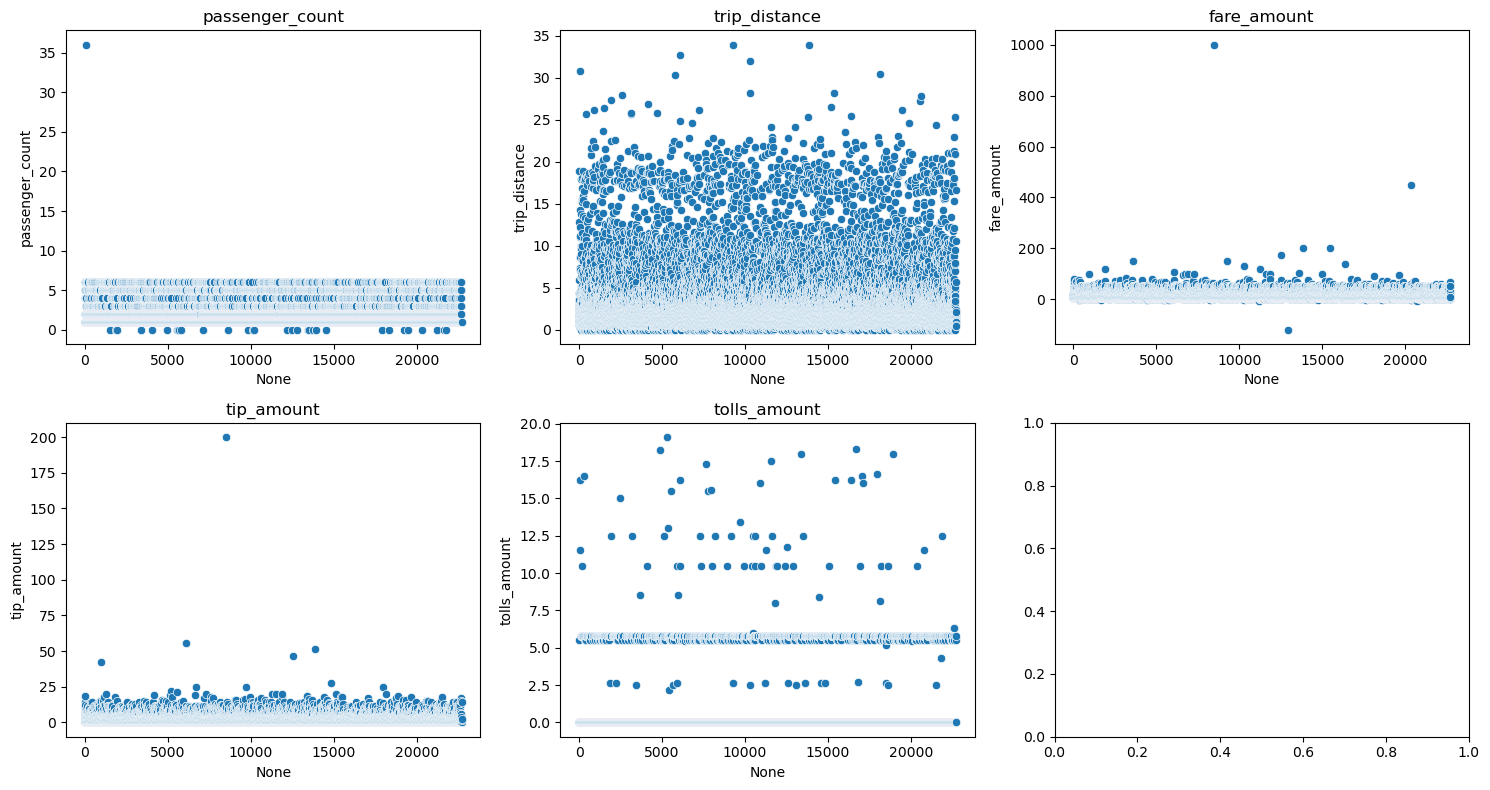

In [4]:
#숫자형 변수 추출
num_cols = df.select_dtypes(include = 'number')
print(num_cols)

# 숫자형 변수에 대해 sctter plot
fig, axes = plt.subplots(2,3,figsize=(15,8))
axes = axes.flatten()

for i,col in enumerate(num_cols):
    sns.scatterplot(
        x=df.index,
        y=df[col],
        ax=axes[i]
    )
    axes[i].set_title(col)


plt.tight_layout()
plt.show()

describe와 scatter plot을 확인한 결과
1. 택시인데 passenger_count 승객 수가 36명은 말이 안됨 삭제 예정
2. 요금 fare_amount 999.99
3. 요금 400 근처 값 확인 필요
4. 요금 마이너스 값 말이 안됨. 삭제 예정
5. tip_amount 확인 필요


In [5]:

#요금 999, 450
df['fare_amount'] = pd.to_numeric(df['fare_amount'],errors='coerce')
df[df['fare_amount'] >999]

df[df['fare_amount'] >350]


,passenger_name,tpep_pickup_datetime,tpep_dropoff_datetime,payment_method,passenger_count,trip_distance,fare_amount,tip_amount,tolls_amount
8478,Alexis Hanson,02/06/2017 5:50:10 AM,02/06/2017 5:51:08 AM,Credit Card,1,2.6,999.99,200.0,0.0
20314,Nicholas Thomas,12/19/2017 9:40:46 AM,12/19/2017 9:40:55 AM,Cash,2,0.0,450.00,0.0,0.0


요금 999.99 tip 200 **거리 2.6**
거리에 비해 요금. 팁 이상함. 삭제 예정

요금 450 **거리 0**
이동한게 없는데, 요금 450. 취소 패널티라고 생각해봐도 과함. 삭제 예정


In [6]:
del_invalid = (
    df['fare_amount'].isna() |
    (df['fare_amount'] < 0) |
    (df['fare_amount'] >= 350) |
    (df['passenger_count'] > 10)
)


del_invalid
df = df[~del_invalid]
df.isna().mean()

passenger_name           0.0
tpep_pickup_datetime     0.0
tpep_dropoff_datetime    0.0
payment_method           0.0
passenger_count          0.0
trip_distance            0.0
fare_amount              0.0
tip_amount               0.0
tolls_amount             0.0
dtype: float64

1% 이하 결측치, 요금 0미만, 요금 450,999 , 승객 36명 고객 데이터를 삭제함


In [7]:

df.info()

df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])
df['tpep_dropoff_datetime'] = pd.to_datetime(df['tpep_dropoff_datetime'])

df['time'] = df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']
df['time']
df['trip_time_min']=df['time'].dt.total_seconds()/60
df['trip_time_min']

df['hour'] = df['tpep_pickup_datetime'].dt.hour
df['hour']

print(df.groupby('hour')['fare_amount'].mean())
df['weekday'] = df['tpep_pickup_datetime'].dt.weekday
df['weekday']
print(df.groupby('weekday')['fare_amount'].mean())

<class 'pandas.core.frame.DataFrame'>
Index: 22681 entries, 0 to 22700
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   passenger_name         22681 non-null  object 
 1   tpep_pickup_datetime   22681 non-null  object 
 2   tpep_dropoff_datetime  22681 non-null  object 
 3   payment_method         22681 non-null  object 
 4   passenger_count        22681 non-null  int64  
 5   trip_distance          22681 non-null  float64
 6   fare_amount            22681 non-null  float64
 7   tip_amount             22681 non-null  float64
 8   tolls_amount           22681 non-null  float64
dtypes: float64(4), int64(1), object(4)
memory usage: 1.7+ MB
hour
0     13.212925
1     11.801905
2     12.206494
3     13.534843
4     14.789362
5     15.305556
6     13.071824
7     11.553738
8     12.320128
9     12.470270
10    12.725962
11    13.335327
12    12.939523
13    13.141083
14    13.654003
15    13.816252
16

픽업시간에서 드랍시간을 빼서 총 운행시간을 구하고 이것 역시 단변량 분석을 하면 좋겠다고 생각해서 변환함


In [8]:
#숫자형 변수 추출
num_cols = df.select_dtypes(include = 'number')
print(num_cols)


num_cols = [
    col for col in num_cols
    if col not in ['time', 'hour', 'weekday']
]

num_cols

       passenger_count  trip_distance  fare_amount  tip_amount  tolls_amount  \
0                    6           3.34         13.0        2.76          0.00   
1                    1           1.80         16.0        4.00          0.00   
2                    1           1.00          6.5        1.45          0.00   
3                    1           3.70         20.5        6.39          0.00   
4                    1           4.37         16.5        0.00          0.00   
...                ...            ...          ...         ...           ...   
22696                3           0.61          4.0        0.00          0.00   
22697                1          16.71         52.0       14.64          5.76   
22698                1           0.42          4.5        0.00          0.00   
22699                1           2.36         10.5        1.70          0.00   
22700                1           2.10         11.0        2.35          0.00   

                 time  trip_time_min  h

['passenger_count',
 'trip_distance',
 'fare_amount',
 'tip_amount',
 'tolls_amount',
 'trip_time_min']

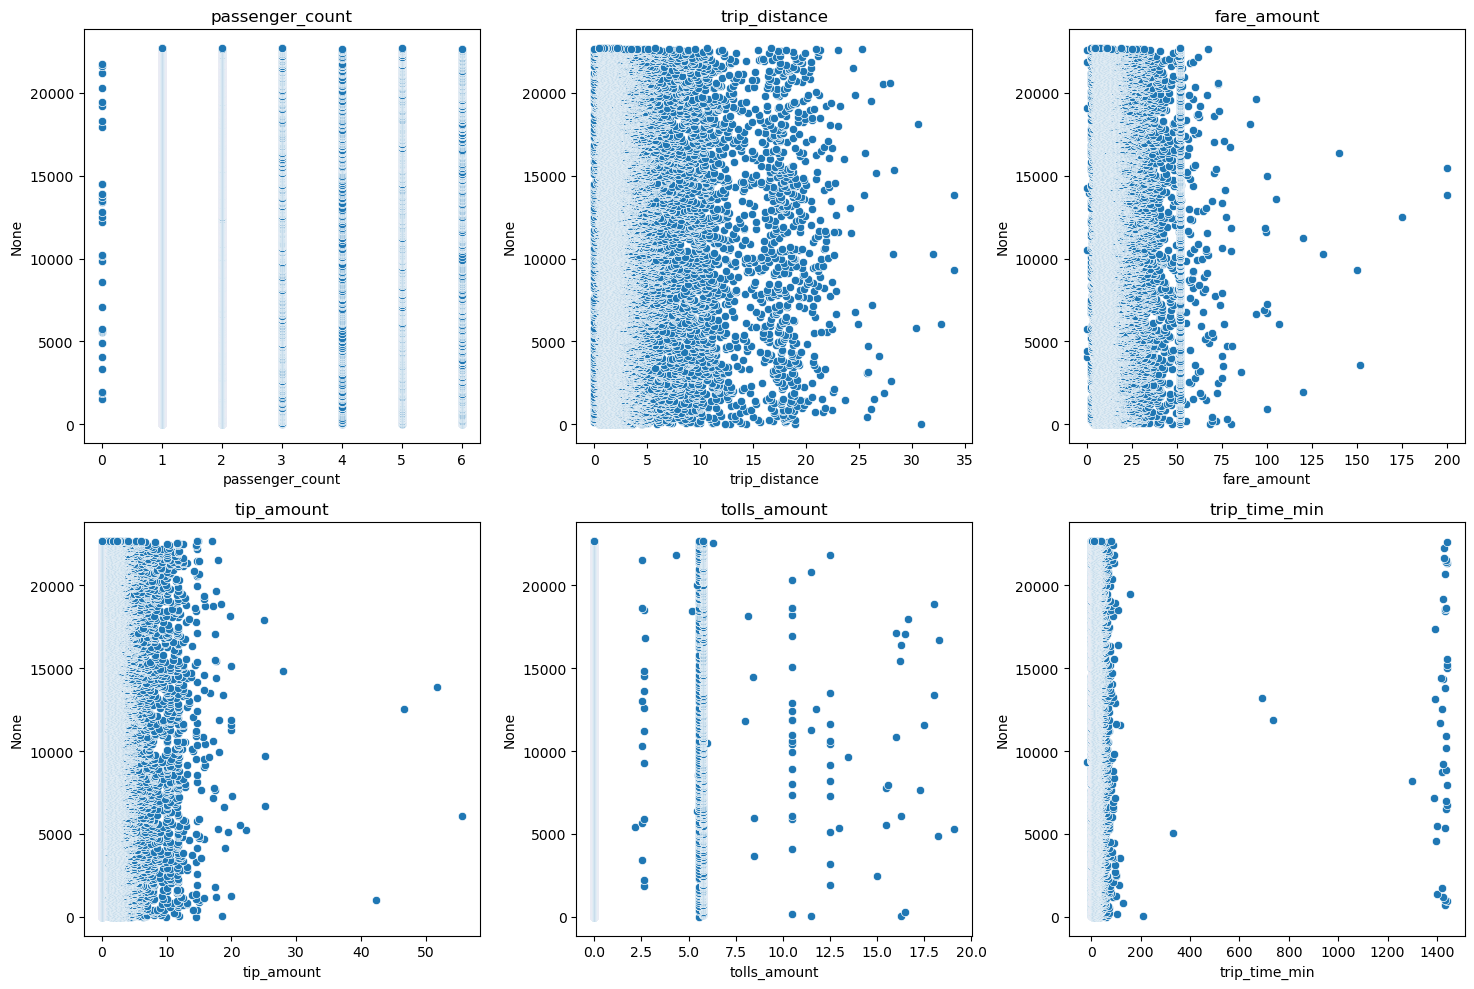

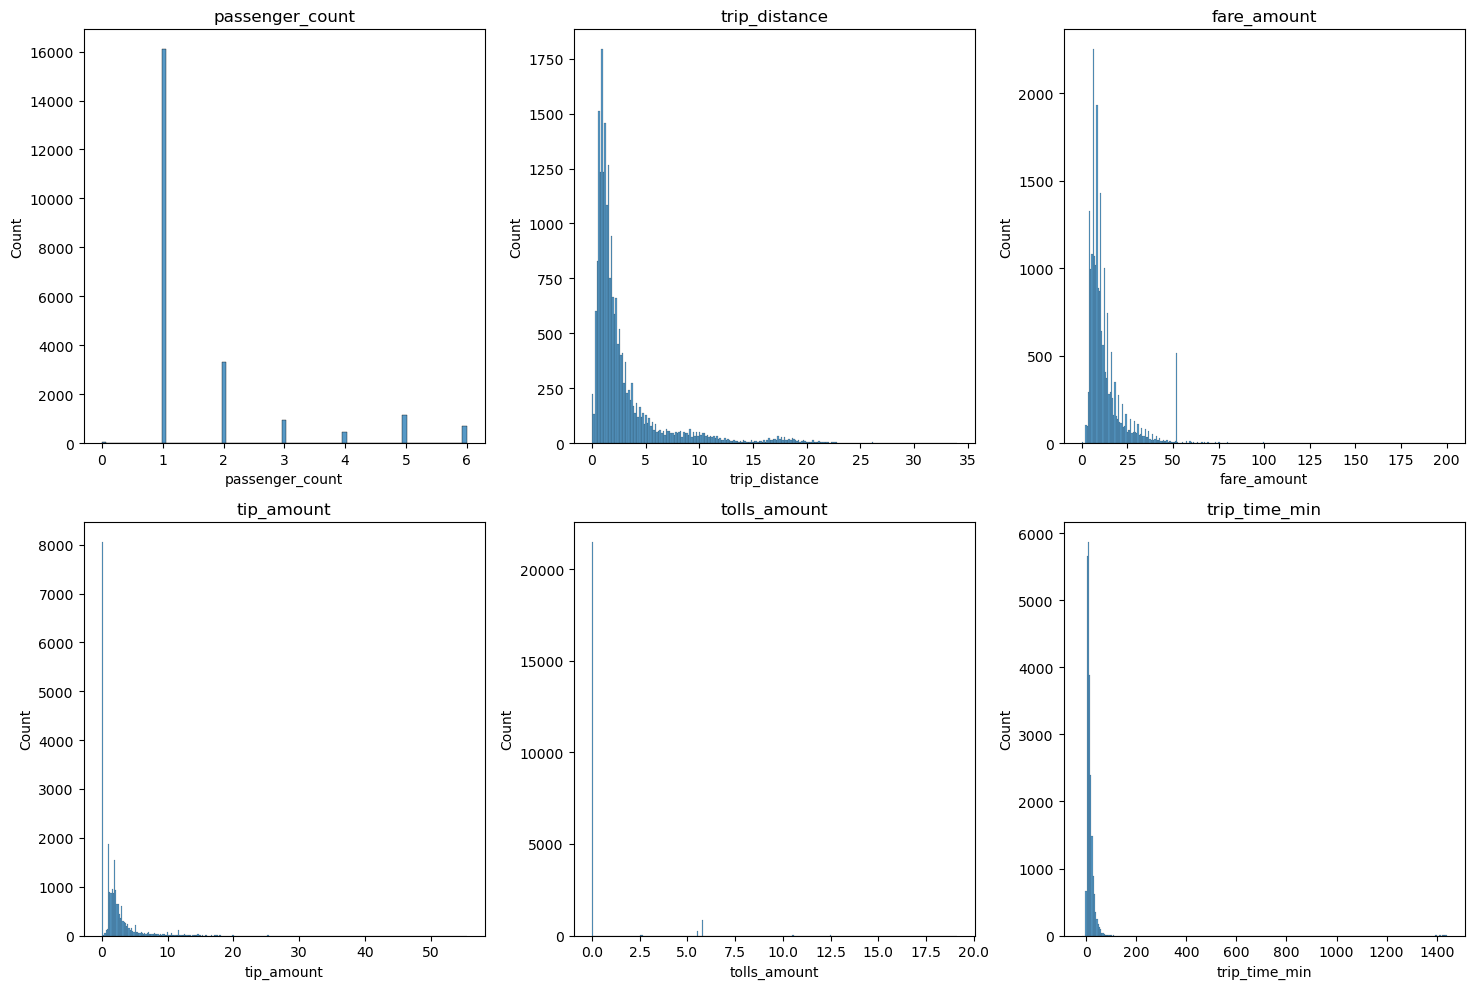

In [9]:


# 숫자형 변수에 대해 sctter plot
fig, axes = plt.subplots(2,3,figsize=(15,10))
axes = axes.flatten()

for i,col in enumerate(num_cols):
    sns.scatterplot(        
        x=df[col],
        y=df.index,
        ax=axes[i]
    )
    axes[i].set_title(col)


plt.tight_layout()
plt.show()


#히스토그램
fig, axes = plt.subplots(2,3,figsize=(15,10))
axes = axes.flatten()

for i,col in enumerate(num_cols):
    mean_val = df[col].mean()
    sns.histplot(
        df[col],
        ax=axes[i]
    )
    axes[i].set_title(col)
    #axes[i].axvline(mean_val, color='red', linestyle='--', linewidth=2, label='Mean')

plt.tight_layout()
plt.show()



In [10]:

df[df['trip_time_min'] >1200].describe()
df[df['trip_time_min']> 1200].count()
(df['trip_time_min'] >1200).mean()


np.float64(0.0018076804373704863)

요금이 52달러 이하이면서 운행시간이 약 1200분 이상인 경우가 41건있음
1200분(약20시간) 이상

20시간 이상인데 요금이 저렇게 낮은건 말이 안됨
drop 시간이 잘못찍혔다고 생각됨
전체의 약 0.2%로 삭제를 하는게 나을 것이라 판단됨

In [11]:
df = df[df['trip_time_min'] < 1200]
df.describe()


,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,fare_amount,tip_amount,tolls_amount,time,trip_time_min,hour,weekday
count,22640,22640,22640.000000,22640.000000,22640.000000,22640.000000,22640.000000,22640,22640.000000,22640.000000,22640.000000
mean,2017-06-29 06:08:34.289796864,2017-06-29 06:22:59.265150208,1.641122,2.913571,12.972348,1.829473,0.312847,0 days 00:14:24.975353356,14.416256,13.726590,3.023940
min,2017-01-01 00:08:25,2017-01-01 00:17:20,0.000000,0.000000,0.000000,0.000000,0.000000,-1 days +23:43:01,-16.983333,0.000000,0.000000
25%,2017-03-30 00:15:22.750000128,2017-03-30 00:26:26.750000128,1.000000,0.990000,6.500000,0.000000,0.000000,0 days 00:06:39,6.650000,9.000000,1.000000
50%,2017-06-23 12:04:22,2017-06-23 12:21:59,1.000000,1.610000,9.500000,1.355000,0.000000,0 days 00:11:10,11.166667,14.000000,3.000000
75%,2017-10-02 09:55:50.750000128,2017-10-02 10:09:09,2.000000,3.060000,14.500000,2.450000,0.000000,0 days 00:18:19,18.316667,19.000000,5.000000
max,2017-12-31 23:45:30,2017-12-31 23:49:24,6.000000,33.960000,200.010000,55.500000,19.100000,0 days 12:16:03,736.050000,23.000000,6.000000
std,NaN,NaN,1.283711,3.651890,11.096796,2.473112,1.400010,0 days 00:13:33.683757393,13.561396,6.222928,1.951248


시간이 600~800분 사이도 확인 필요
시간이 마이너스인 값이 존재. 이것도 삭제 필요


In [12]:
df[df['trip_time_min'] < 0].count()
df = df[df['trip_time_min']>=0]

df.describe()

df[df['trip_time_min'] >600]
df = df[df['trip_time_min']<600]

df.count()


passenger_name           22637
tpep_pickup_datetime     22637
tpep_dropoff_datetime    22637
payment_method           22637
passenger_count          22637
trip_distance            22637
fare_amount              22637
tip_amount               22637
tolls_amount             22637
time                     22637
trip_time_min            22637
hour                     22637
weekday                  22637
dtype: int64

택시 탑승 및 하차 시간을 활용할 수 있을지 고민해보세요.
[힌트] 택시의 주행 시간과 주행 거리, 요금 등의 상관 관계도 살펴볼 수 있겠죠?
Credit Card와 Debit Card를 구분없이 "Card"라는 이름으로 만들어 보세요.

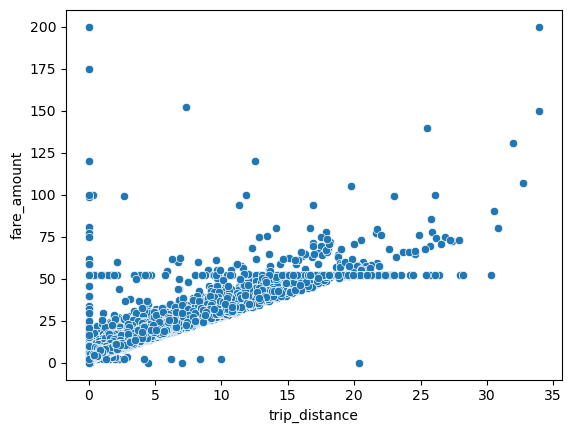

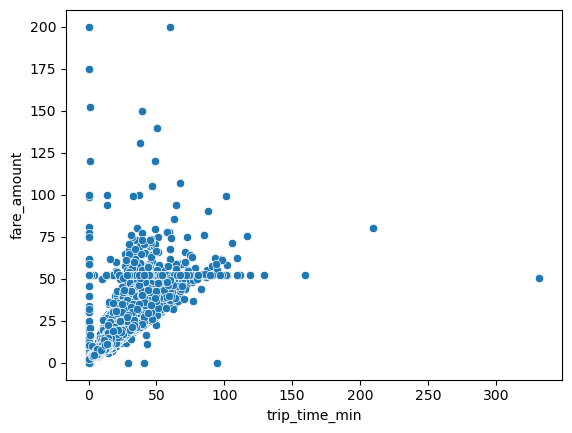

In [13]:
sns.scatterplot(
    x=df['trip_distance'],
    y=df['fare_amount']
)

plt.show()

sns.scatterplot(
    x=df['trip_time_min'],
    y= df['fare_amount']
)

plt.show()


In [15]:
df[df['fare_amount'] == 50].count()


df_50= df[df['fare_amount'].between(48,60)]
df_50['fare_amount'].describe()
df[df['fare_amount'] == 52].count()
(df['fare_amount'] == 52).mean()


np.float64(0.022617838052745504)

운행 거리와 요금 간에 선형관계도 있지만, 일부 52달러로 고정된 금액이 부과된 경우도 있음.
514건으로 전체의 약 2.2%
특정조건에 대해 52달러 정액권이 있는 것으로 예측됨



거리가 0인데, 요금이 부과된 사람들도 확인이 필요함

In [14]:
df[df['trip_distance']==0].count()
df[df['trip_distance']==0].describe()
(df['trip_distance']==0).mean()


(
    (df['trip_distance'] == 0) &
    (df['fare_amount'] > 0)
).mean()

np.float64(0.006317091487387905)

이동 거리가 0인데, 요금이 발생했음으로
요금 예측을 하기위한 모델에는 맞지 않는다고 볼 수 있고
전체의 0.6% 로 삭제해도 된다고 판단함

In [16]:
del_cols = (
    (df['trip_distance'] == 0) &
    (df['fare_amount'] > 0)
)

del_cols.sum()

df_before =df.copy()
df = df[
    ~(
        (df['trip_distance'] == 0) &
        (df['fare_amount'] > 0)
    )
]

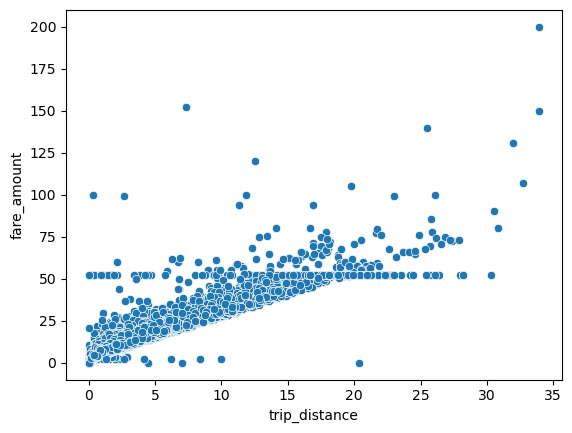

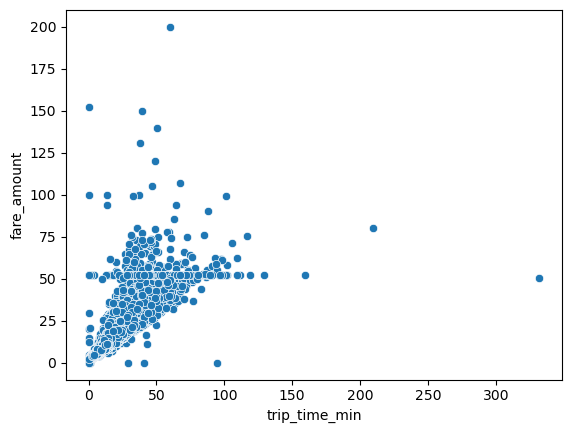

In [17]:
sns.scatterplot(
    x=df['trip_distance'],
    y=df['fare_amount']
)

plt.show()

sns.scatterplot(
    x=df['trip_time_min'],
    y= df['fare_amount']
)

plt.show()

In [18]:
df['payment_method'].value_counts()

df['payment_method'] = df['payment_method'].apply(
        lambda x: 'Card' if x in ['Credit Card','Debit Card'] else x
)

df['payment_method'].value_counts()

payment_method
Card    11401
Cash    11093
Name: count, dtype: int64

In [19]:
df.info()


corr_cols = ['passenger_count','trip_distance','fare_amount','tip_amount','tolls_amount','time','trip_time_min','hour','weekday']
corr_cols

df_corr = df[corr_cols]
corr_matrix = df_corr.corr()
print(corr_matrix)

<class 'pandas.core.frame.DataFrame'>
Index: 22494 entries, 0 to 22700
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype          
---  ------                 --------------  -----          
 0   passenger_name         22494 non-null  object         
 1   tpep_pickup_datetime   22494 non-null  datetime64[ns] 
 2   tpep_dropoff_datetime  22494 non-null  datetime64[ns] 
 3   payment_method         22494 non-null  object         
 4   passenger_count        22494 non-null  int64          
 5   trip_distance          22494 non-null  float64        
 6   fare_amount            22494 non-null  float64        
 7   tip_amount             22494 non-null  float64        
 8   tolls_amount           22494 non-null  float64        
 9   time                   22494 non-null  timedelta64[ns]
 10  trip_time_min          22494 non-null  float64        
 11  hour                   22494 non-null  int32          
 12  weekday                22494 non-null  int32       

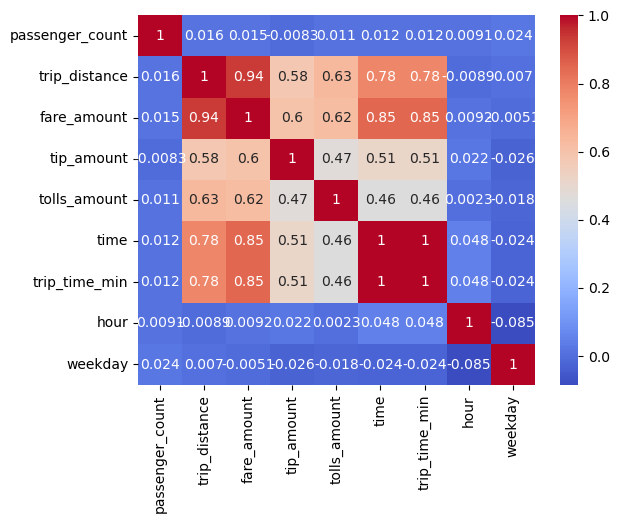

In [20]:
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap = 'coolwarm'
)

plt.show()

fare_amount, trip_distance 강한 상관 관계 0.94
fare_amount, time 중 상관관계 0.85
trip_distance, trip_time_min 중
tolls_amount, fare_acmount 중


passenger_count는 대부분 변수와 0.02 이하 상관관계로 큰 영향이 없음



가설1 : 택시 요금은 거리와 선형 관계를 가진다
가설2 : 특정 조건에 대해서는 택시 요금은 거리 상관없이 정액 요금 52달러가 부과된다.